In [1]:
import json
import os
import subprocess
from pathlib import Path

# Define paths
project_root = Path("/home/petar/GraphProject/GraphProject")
bench_binary = project_root / "build" / "benchmarks" / "run_benchmarks"

output_file = project_root / "build" / "results_advanced.json"

# Run the benchmark
if not bench_binary.exists():
    print(f"Benchmark binary not found: {bench_binary}")
else:
    print(f"Running benchmarks (this might take a minute)...")
    result = subprocess.run(
        [
            str(bench_binary),
            f"--benchmark_out={output_file}",
            "--benchmark_out_format=json",
        ],
        capture_output=True,
        text=True,
    )
    if result.returncode == 0:
        print(f"Success! Results saved to: {output_file}")
    else:
        print("Error executing benchmark:", result.stderr)

Running benchmarks (this might take a minute)...
Success! Results saved to: /home/petar/GraphProject/GraphProject/build/results_advanced.json


In [2]:
import json
import collections

# Initialize a nested dictionary to store metrics: data[benchmark_type][graph_type] = {'N': [], 'tp': []}
data = collections.defaultdict(lambda: collections.defaultdict(lambda: {"N": [], "tp": [], "time": []}))

with open(output_file, "r") as f:
    benchmark_data = json.load(f)

for run in benchmark_data["benchmarks"]:
    name = run["name"]
    vertex_count = int(name.split("/")[-1])
    exec_time_ms = run["real_time"]
    throughput_meps = run.get("items_per_second", 0.0) / 1_000_000.0
    
    # Determine Graph Type
    if "CSRGraph" in name:
        g_type = "CSRGraph"
    elif "CBListGraph" in name or "_CBList" in name:
        g_type = "CBListGraph"
    else:
        g_type = "NaiveGraph"
        
    # Determine Benchmark Category
    if "BM_NeighborTraversal" in name:
        b_type = "NeighborTraversal"
    elif "BM_TraverseEntireGraph" in name:
        b_type = "TraverseEntireGraph"
    elif "BM_BFS" in name:
        b_type = "BFS"
    elif "BM_Dijkstra" in name:
        b_type = "Dijkstra"
    elif "BM_DynamicEdgeAddition" in name:
        b_type = "DynamicEdgeAddition"
    elif "BM_EdgeInsertion" in name:
        b_type = "InitialInsertion"
    else:
        continue
        
    data[b_type][g_type]["N"].append(vertex_count)
    data[b_type][g_type]["tp"].append(throughput_meps)
    data[b_type][g_type]["time"].append(exec_time_ms)

print("Parsed benchmark categories:", list(data.keys()))

Parsed benchmark categories: ['InitialInsertion', 'NeighborTraversal', 'TraverseEntireGraph', 'BFS', 'Dijkstra', 'DynamicEdgeAddition']


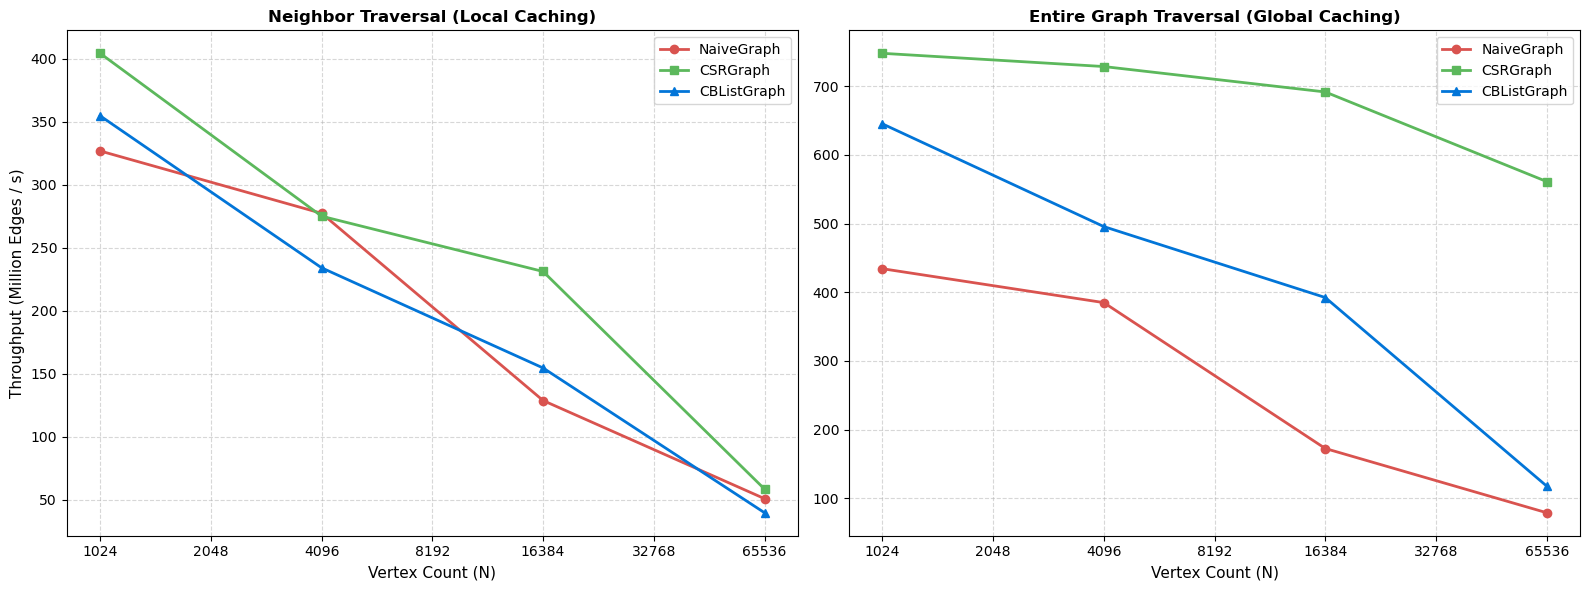

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = {'NaiveGraph': '#d9534f', 'CSRGraph': '#5cb85c', 'CBListGraph': '#0275d8'}
markers = {'NaiveGraph': 'o', 'CSRGraph': 's', 'CBListGraph': '^'}

# Plot 1: Neighbor Traversal
for g_type, metrics in data["NeighborTraversal"].items():
    ax1.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)
ax1.set_xscale("log", base=2)
ax1.set_title("Neighbor Traversal (Local Caching)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Vertex Count (N)", fontsize=11)
ax1.set_ylabel("Throughput (Million Edges / s)", fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()
ax1.xaxis.set_major_formatter(ScalarFormatter())

# Plot 2: Entire Graph Traversal (GTChain)
for g_type, metrics in data["TraverseEntireGraph"].items():
    ax2.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)
ax2.set_xscale("log", base=2)
ax2.set_title("Entire Graph Traversal (Global Caching)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Vertex Count (N)", fontsize=11)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()
ax2.xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

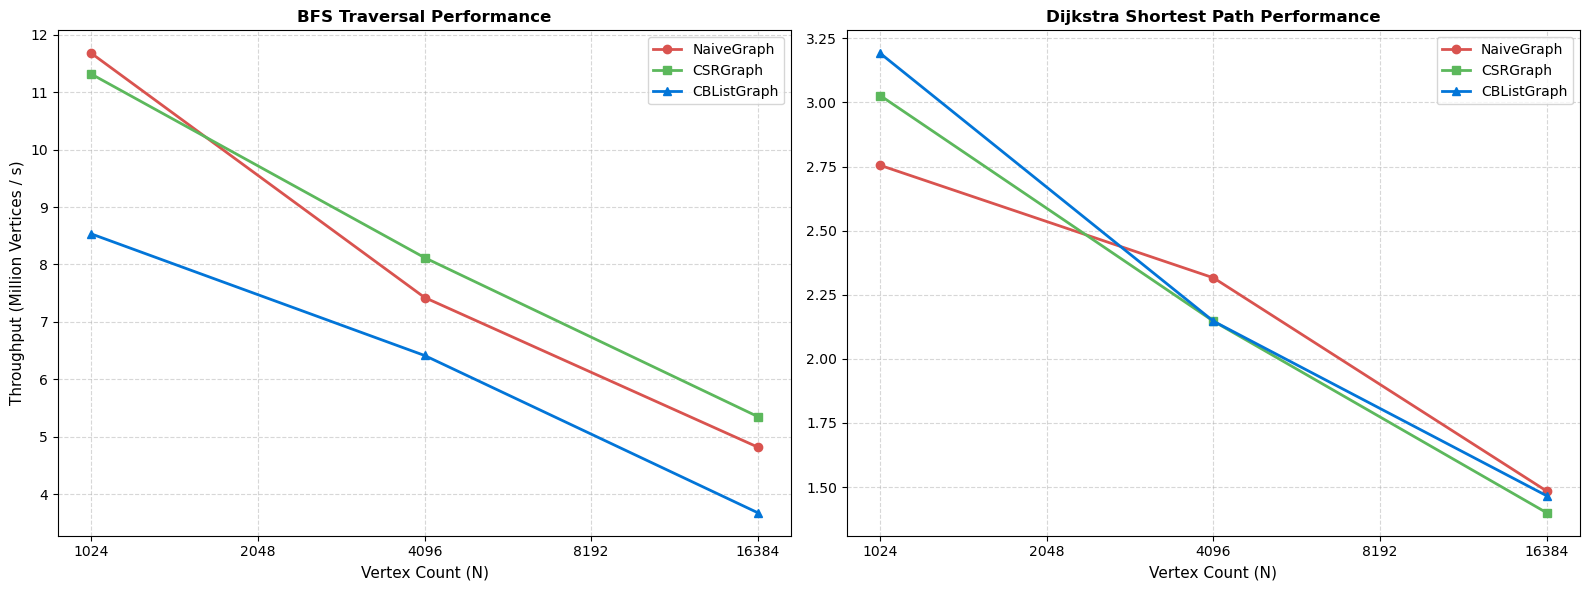

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: BFS
for g_type, metrics in data["BFS"].items():
    ax1.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)
ax1.set_xscale("log", base=2)
ax1.set_title("BFS Traversal Performance", fontsize=12, fontweight="bold")
ax1.set_xlabel("Vertex Count (N)", fontsize=11)
ax1.set_ylabel("Throughput (Million Vertices / s)", fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()
ax1.xaxis.set_major_formatter(ScalarFormatter())

# Plot 2: Dijkstra
for g_type, metrics in data["Dijkstra"].items():
    ax2.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)
ax2.set_xscale("log", base=2)
ax2.set_title("Dijkstra Shortest Path Performance", fontsize=12, fontweight="bold")
ax2.set_xlabel("Vertex Count (N)", fontsize=11)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()
ax2.xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

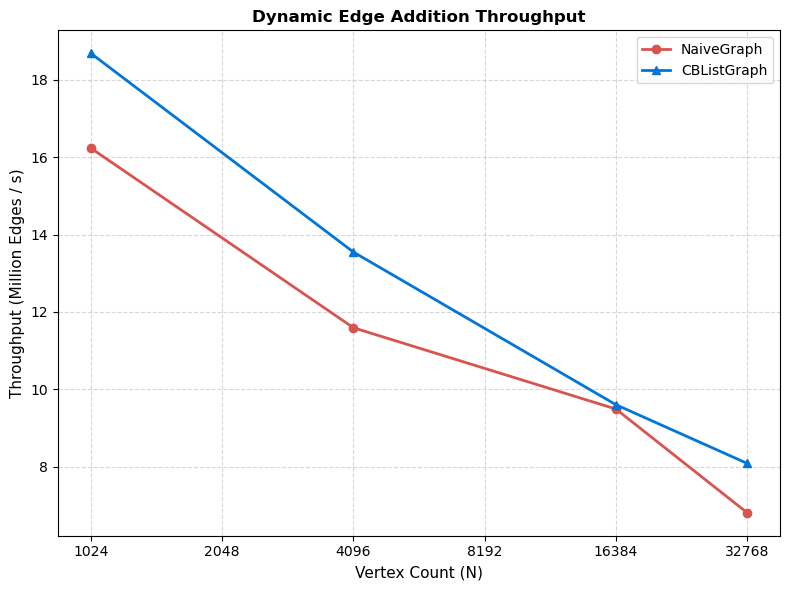

In [5]:
plt.figure(figsize=(8, 6))

for g_type, metrics in data["DynamicEdgeAddition"].items():
    plt.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)

plt.xscale("log", base=2)
plt.title("Dynamic Edge Addition Throughput", fontsize=12, fontweight="bold")
plt.xlabel("Vertex Count (N)", fontsize=11)
plt.ylabel("Throughput (Million Edges / s)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

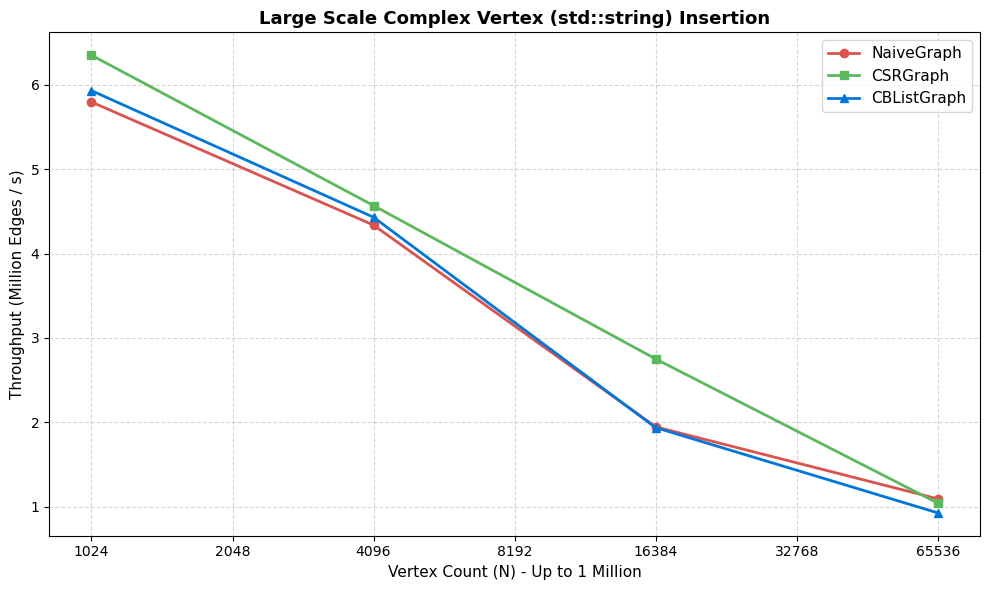

In [6]:
import json
import collections
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

# Load results specifically for the complex vertex benchmark
complex_file = Path("/home/petar/GraphProject/GraphProject/build/results_complex.json")
complex_data = collections.defaultdict(lambda: {"N": [], "tp": []})

with open(complex_file, "r") as f:
    bench_data = json.load(f)

for run in bench_data["benchmarks"]:
    name = run["name"]
    vertex_count = int(name.split("/")[-1])
    throughput_meps = run.get("items_per_second", 0.0) / 1_000_000.0
    
    if "CSRGraph" in name:
        g_type = "CSRGraph"
    elif "CBListGraph" in name:
        g_type = "CBListGraph"
    else:
        g_type = "NaiveGraph"
        
    complex_data[g_type]["N"].append(vertex_count)
    complex_data[g_type]["tp"].append(throughput_meps)

# Plotting
plt.figure(figsize=(10, 6))
colors = {'NaiveGraph': '#d9534f', 'CSRGraph': '#5cb85c', 'CBListGraph': '#0275d8'}
markers = {'NaiveGraph': 'o', 'CSRGraph': 's', 'CBListGraph': '^'}

for g_type, metrics in complex_data.items():
    plt.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)

plt.xscale("log", base=2)
plt.title("Large Scale Complex Vertex (std::string) Insertion", fontsize=13, fontweight="bold")
plt.xlabel("Vertex Count (N) - Up to 1 Million", fontsize=11)
plt.ylabel("Throughput (Million Edges / s)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=11)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


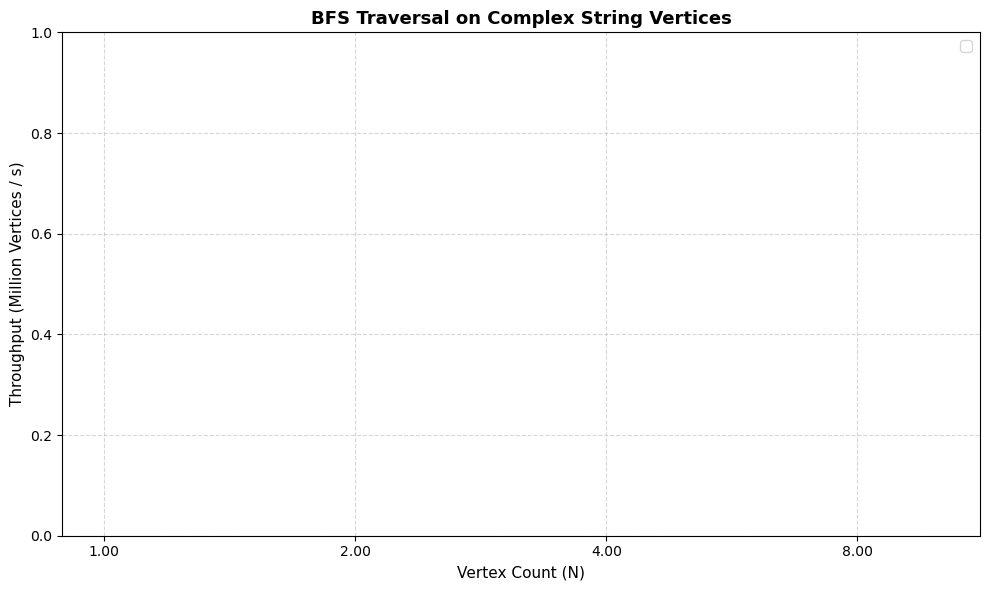

In [7]:
import json
import collections
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

complex_file = Path("/home/petar/GraphProject/GraphProject/build/results_complex.json")
complex_bfs_data = collections.defaultdict(lambda: {"N": [], "tp": []})

with open(complex_file, "r") as f:
    bench_data = json.load(f)

for run in bench_data["benchmarks"]:
    name = run["name"]
    # Filtriraj samo BFS na kompleksnim stringovima
    if "BM_LargeComplexVertex_BFS" not in name:
        continue
        
    vertex_count = int(name.split("/")[-1])
    throughput_meps = run.get("items_per_second", 0.0) / 1_000_000.0
    
    if "CSRGraph" in name:
        g_type = "CSRGraph"
    elif "CBListGraph" in name:
        g_type = "CBListGraph"
    else:
        g_type = "NaiveGraph"
        
    complex_bfs_data[g_type]["N"].append(vertex_count)
    complex_bfs_data[g_type]["tp"].append(throughput_meps)

plt.figure(figsize=(10, 6))
colors = {'NaiveGraph': '#d9534f', 'CSRGraph': '#5cb85c', 'CBListGraph': '#0275d8'}
markers = {'NaiveGraph': 'o', 'CSRGraph': 's', 'CBListGraph': '^'}

for g_type, metrics in complex_bfs_data.items():
    if len(metrics["N"]) > 0:
        plt.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)

plt.xscale("log", base=2)
plt.title("BFS Traversal on Complex String Vertices", fontsize=13, fontweight="bold")
plt.xlabel("Vertex Count (N)", fontsize=11)
plt.ylabel("Throughput (Million Vertices / s)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=11)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

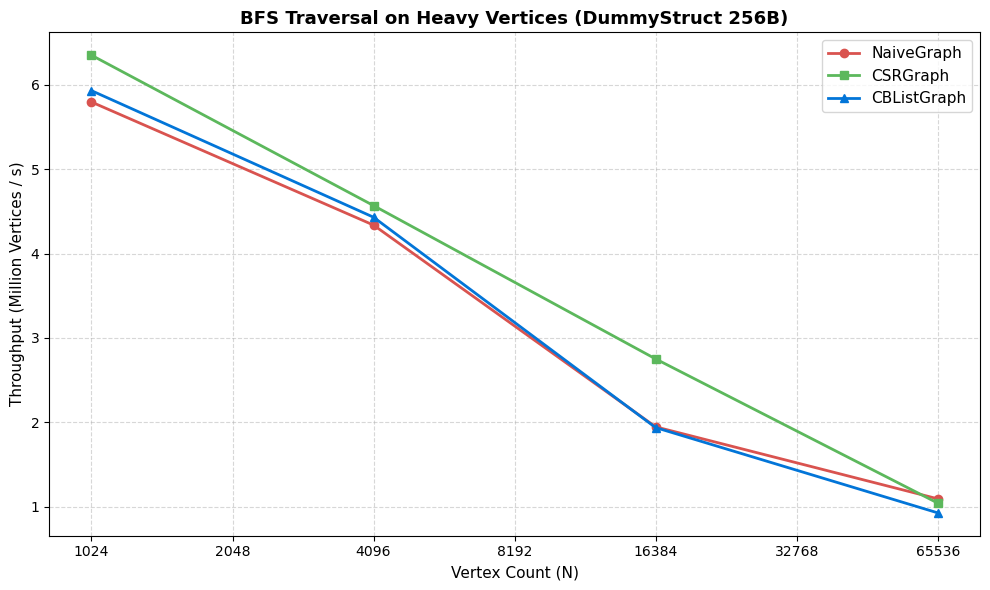

In [8]:
import json
import collections
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

# Parsiranje JSON-a
heavy_file = Path("/home/petar/GraphProject/GraphProject/build/results_complex.json")
heavy_bfs_data = collections.defaultdict(lambda: {"N": [], "tp": []})

with open(heavy_file, "r") as f:
    bench_data = json.load(f)

for run in bench_data["benchmarks"]:
    name = run["name"]
    # Filtriraj samo testove s teškom strukturom
    if "BM_HeavyVertex_BFS" not in name:
        continue
        
    vertex_count = int(name.split("/")[-1])
    throughput_meps = run.get("items_per_second", 0.0) / 1_000_000.0
    
    if "CSRGraph" in name:
        g_type = "CSRGraph"
    elif "CBListGraph" in name:
        g_type = "CBListGraph"
    else:
        g_type = "NaiveGraph"
        
    heavy_bfs_data[g_type]["N"].append(vertex_count)
    heavy_bfs_data[g_type]["tp"].append(throughput_meps)

# Crtanje grafa
plt.figure(figsize=(10, 6))
colors = {'NaiveGraph': '#d9534f', 'CSRGraph': '#5cb85c', 'CBListGraph': '#0275d8'}
markers = {'NaiveGraph': 'o', 'CSRGraph': 's', 'CBListGraph': '^'}

for g_type, metrics in heavy_bfs_data.items():
    if len(metrics["N"]) > 0:
        plt.plot(metrics["N"], metrics["tp"], marker=markers[g_type], color=colors[g_type], label=g_type, linewidth=2)

plt.xscale("log", base=2)
plt.title("BFS Traversal on Heavy Vertices (DummyStruct 256B)", fontsize=13, fontweight="bold")
plt.xlabel("Vertex Count (N)", fontsize=11)
plt.ylabel("Throughput (Million Vertices / s)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=11)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()